# Carena et al. Figure 5 Reproduction with the User GN Model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/paper/hcf-optimum-launch-power-reproduction/new_research/Carena_Fig5_User_GN_Model_Validation_Executed.ipynb)

## 논문 Fig. 5와 사용자 GN 모델의 최대 도달거리 교차검증

이 Colab은 A. Carena *et al.*, **“Modeling of the Impact of Nonlinear Propagation Effects in Uncompensated Optical Coherent Transmission Links,”** JLT 30(10), 2012의 Fig. 5를 사용자 GN 모델로 검증한다.

- 논문: https://ieeexplore.ieee.org/document/6158564
- 비교 대상: PSCF, SMF, NZDSF
- 변조방식: PM-BPSK, PM-QPSK, PM-8QAM, PM-16QAM
- 사용자 GN 식과 다중-span 누적 지수 $N_{span}^{1.05}$는 변경하지 않는다.
- 논문 Fig. 3의 required OSNR과 Fig. 5의 simulation markers는 그림에서 digitizing한 근삿값이다.
- Fig. 5의 도달거리는 100 km span 단위로 반올림하였다.

> 이 파일은 기존 노트북을 수정하지 않고 새로 작성한 실행 완료 Colab이다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.55,
    "font.size": 10,
})

H_PLANCK = 6.62607015e-34
C0 = 299792458.0
LAMBDA_M = 1550e-9
F0_HZ = C0 / LAMBDA_M
RS_HZ = 32e9
PAYLOAD_RS_GBD = 25.0
N_CHANNELS = 9
CUT_INDEX = 4
SPAN_LENGTH_KM = 100.0
NOISE_FIGURE_DB = 5.0
NLI_COHERENCE_EXPONENT = 0.05  # user's existing GN model
MAX_SPANS = 300
LAUNCH_DBM = np.arange(-10.0, 8.001, 0.05)


@dataclass(frozen=True)
class Fiber:
    label: str
    alpha_db_km: float
    dispersion_ps_nm_km: float
    gamma_w_inv_km: float
    color: str

    @property
    def beta2_ps2_km(self):
        d_si = self.dispersion_ps_nm_km * 1e-6
        beta2_s2_km = -(LAMBDA_M**2 / (2 * np.pi * C0)) * d_si * 1e3
        return float(beta2_s2_km * 1e24)


FIBERS = {
    "PSCF": Fiber("PSCF", 0.18, 20.1, 0.9, "#2ca02c"),
    "SMF": Fiber("SMF", 0.22, 16.7, 1.3, "#ff7f0e"),
    "NZDSF": Fiber("NZDSF", 0.22, 3.8, 1.5, "#9467bd"),
}

fiber_input_table = pd.DataFrame([
    {
        "Fiber": key,
        "alpha [dB/km]": f.alpha_db_km,
        "D [ps/(nm km)]": f.dispersion_ps_nm_km,
        "beta2 [ps^2/km]": f.beta2_ps2_km,
        "gamma [1/(W km)]": f.gamma_w_inv_km,
    }
    for key, f in FIBERS.items()
])

system_input_table = pd.DataFrame([
    ["WDM channels", N_CHANNELS, ""],
    ["Gross symbol rate", RS_HZ / 1e9, "GBd"],
    ["Net payload symbol rate", PAYLOAD_RS_GBD, "GBd"],
    ["Span length", SPAN_LENGTH_KM, "km"],
    ["EDFA noise figure", NOISE_FIGURE_DB, "dB"],
    ["Target BER", 1e-3, ""],
    ["NLI coherence exponent", NLI_COHERENCE_EXPONENT, ""],
], columns=["Parameter", "Value", "Unit"])

print("SYSTEM INPUTS")
print(system_input_table.to_string(index=False))
print("\nFIBER INPUTS")
print(fiber_input_table.round(4).to_string(index=False))

SYSTEM INPUTS
              Parameter   Value Unit
           WDM channels   9.000     
      Gross symbol rate  32.000  GBd
Net payload symbol rate  25.000  GBd
            Span length 100.000   km
      EDFA noise figure   5.000   dB
             Target BER   0.001     
 NLI coherence exponent   0.050     

FIBER INPUTS
Fiber  alpha [dB/km]  D [ps/(nm km)]  beta2 [ps^2/km]  gamma [1/(W km)]
 PSCF           0.18            20.1         -25.6365               0.9
  SMF           0.22            16.7         -21.3000               1.3
NZDSF           0.22             3.8          -4.8467               1.5


## 논문 Fig. 3·5 digitizing 입력

Fig. 5의 실선은 논문 GN 모델이고 마커는 split-step simulation 결과이다. 본 검증에서는 사용자 GN 모델을 논문의 simulation marker와 비교한다.

Fig. 3의 required OSNR은 BER $10^{-3}$를 만족하는 back-to-back sensitivity이다. OSNR(0.1 nm)을 matched-band SNR로 변환한다.

$$
SNR_{req,dB}=OSNR_{req,dB}+10\log_{10}\left(\frac{12.5\ \mathrm{GHz}}{32\ \mathrm{GHz}}\right)
$$

순 스펙트럼 효율은 다음과 같다.

$$
SE=\frac{M R_{payload}}{\Delta f},\qquad R_{payload}=25\ \mathrm{GBd}
$$


In [2]:
OSNR_REQUIRED_DB = {
    "PM-BPSK": {50: 10.95, 38.4: 11.12, 35.2: 11.38, 33.6: 11.77, 32.8: 12.05, 32: 12.40},
    "PM-QPSK": {50: 13.95, 38.4: 14.15, 35.2: 14.65, 33.6: 15.20, 32.8: 15.65, 32: 16.25},
    "PM-8QAM": {50: 18.10, 38.4: 18.52, 35.2: 19.69, 33.6: 21.62, 32.8: 24.40},
    "PM-16QAM": {50: 20.65, 38.4: 21.85, 36.8: 22.35, 35.2: 24.54},
}

BITS_PER_SYMBOL = {
    "PM-BPSK": 2,
    "PM-QPSK": 4,
    "PM-8QAM": 6,
    "PM-16QAM": 8,
}

# Fig. 5 simulation markers, digitized and rounded to one 100-km span.
PAPER_REACH_KM = {
    "PSCF": {
        "PM-BPSK": {50: 18000, 38.4: 15800, 35.2: 14400, 33.6: 12300, 32.8: 11700, 32: 11300},
        "PM-QPSK": {50: 9000, 38.4: 7900, 35.2: 7000, 33.6: 6000, 32.8: 5700, 32: 5000},
        "PM-8QAM": {50: 3600, 38.4: 3100, 35.2: 2300, 33.6: 1400, 32.8: 800},
        "PM-16QAM": {50: 1600, 38.4: 1400, 36.8: 1100, 35.2: 700},
    },
    "SMF": {
        "PM-BPSK": {50: 7800, 38.4: 7000, 35.2: 6200, 33.6: 5800, 32.8: 5400, 32: 4500},
        "PM-QPSK": {50: 4300, 38.4: 3700, 35.2: 3300, 33.6: 2700, 32.8: 2500, 32: 2300},
        "PM-8QAM": {50: 1700, 38.4: 1400, 35.2: 1000, 33.6: 600, 32.8: 400},
        "PM-16QAM": {50: 800, 38.4: 600, 36.8: 500, 35.2: 300},
    },
    "NZDSF": {
        "PM-BPSK": {50: 5000, 38.4: 4600, 35.2: 4300, 33.6: 4000, 32.8: 3800, 32: 3500},
        "PM-QPSK": {50: 2800, 38.4: 2300, 35.2: 2000, 33.6: 1600, 32.8: 1600, 32: 1400},
        "PM-8QAM": {50: 1000, 38.4: 900, 35.2: 600, 33.6: 400, 32.8: 300},
        "PM-16QAM": {50: 500, 38.4: 400, 36.8: 300, 35.2: 200},
    },
}

spacing_rows = []
for modulation, values in OSNR_REQUIRED_DB.items():
    for spacing, osnr in values.items():
        spacing_rows.append({
            "Modulation": modulation,
            "Spacing [GHz]": spacing,
            "Required OSNR [dB/0.1nm]": osnr,
            "Net SE [bit/s/Hz]": BITS_PER_SYMBOL[modulation] * PAYLOAD_RS_GBD / spacing,
        })
print(pd.DataFrame(spacing_rows).round(4).to_string(index=False))

Modulation  Spacing [GHz]  Required OSNR [dB/0.1nm]  Net SE [bit/s/Hz]
   PM-BPSK           50.0                     10.95             1.0000
   PM-BPSK           38.4                     11.12             1.3021
   PM-BPSK           35.2                     11.38             1.4205
   PM-BPSK           33.6                     11.77             1.4881
   PM-BPSK           32.8                     12.05             1.5244
   PM-BPSK           32.0                     12.40             1.5625
   PM-QPSK           50.0                     13.95             2.0000
   PM-QPSK           38.4                     14.15             2.6042
   PM-QPSK           35.2                     14.65             2.8409
   PM-QPSK           33.6                     15.20             2.9762
   PM-QPSK           32.8                     15.65             3.0488
   PM-QPSK           32.0                     16.25             3.1250
   PM-8QAM           50.0                     18.10             3.0000
   PM-

## 사용자 GN 모델

한 span의 CUT NLI 계수는 사용자 코드의 Cartesian GN 적분을 그대로 사용한다.

$$
\eta_1=\frac{16}{27}\gamma^2\iiint
\left|\frac{1-e^{(-\alpha+j\Delta\beta)L_s}}{\alpha-j\Delta\beta}\right|^2
G(f_1)G(f_2)G(f_1+f_2-f)\,df_1df_2df
$$

도달거리 계산에서도 기존 다중-span 누적식을 유지한다.

$$
SNR(N,P)=\frac{P}{N P_{ASE,span}+\eta_1N^{1.05}P^3}
$$

각 조건에서 채널당 launch power를 독립적으로 sweep하고, required SNR을 만족하는 최대 정수 span 수를 구한다.


In [3]:
def rectangular_wdm_psd(frequency_hz, centers_hz, channel_bandwidth_hz, pch_w=1.0):
    frequency_hz = np.asarray(frequency_hz)
    psd = np.zeros_like(frequency_hz, dtype=float)
    for center in centers_hz:
        psd += (
            np.abs(frequency_hz - center) <= channel_bandwidth_hz / 2
        ) * (pch_w / channel_bandwidth_hz)
    return psd


def numeric_gn_eta_single_span(fiber, spacing_ghz, ngrid=401, n_cut_samples=5):
    spacing_hz = spacing_ghz * 1e9
    centers_hz = (np.arange(N_CHANNELS, dtype=float) - CUT_INDEX) * spacing_hz
    grid_hz = np.linspace(
        centers_hz[0] - RS_HZ / 2,
        centers_hz[-1] + RS_HZ / 2,
        ngrid,
    )
    f1_hz = grid_hz[:, None]
    f2_hz = grid_hz[None, :]
    g1 = rectangular_wdm_psd(grid_hz, centers_hz, RS_HZ)
    beta2_s2_km = fiber.beta2_ps2_km * 1e-24
    alpha_power_km = fiber.alpha_db_km / 4.343
    cut_samples_hz = np.linspace(-RS_HZ / 2, RS_HZ / 2, n_cut_samples)
    gnli_psd = []

    for f_cut_hz in cut_samples_hz:
        f3_hz = f1_hz + f2_hz - f_cut_hz
        g3 = rectangular_wdm_psd(f3_hz, centers_hz, RS_HZ)
        mismatch_km = (
            4 * np.pi**2 * beta2_s2_km
            * (f1_hz - f_cut_hz) * (f2_hz - f_cut_hz)
        )
        link = (
            1 - np.exp((-alpha_power_km + 1j * mismatch_km) * SPAN_LENGTH_KM)
        ) / (alpha_power_km - 1j * mismatch_km)
        integrand = np.abs(link)**2 * g1[:, None] * g1[None, :] * g3
        gnli_psd.append(
            (16 / 27) * fiber.gamma_w_inv_km**2
            * np.trapezoid(np.trapezoid(integrand, grid_hz, axis=1), grid_hz)
        )

    return float(np.trapezoid(gnli_psd, cut_samples_hz))


def ase_per_span_w(fiber):
    gain_linear = 10 ** (fiber.alpha_db_km * SPAN_LENGTH_KM / 10)
    noise_factor = 10 ** (NOISE_FIGURE_DB / 10)
    return H_PLANCK * F0_HZ * noise_factor * RS_HZ * (gain_linear - 1)


def maximum_reach(fiber, eta_single_span, required_osnr_db):
    required_snr_db = required_osnr_db + 10 * np.log10(12.5e9 / RS_HZ)
    required_snr = 10 ** (required_snr_db / 10)
    powers_w = 1e-3 * 10 ** (LAUNCH_DBM / 10)
    spans = np.arange(1, MAX_SPANS + 1, dtype=float)
    ase = spans * ase_per_span_w(fiber)
    reach_for_power = []

    for power_w in powers_w:
        nli = (
            eta_single_span
            * spans ** (1 + NLI_COHERENCE_EXPONENT)
            * power_w**3
        )
        snr = power_w / (ase + nli)
        valid = np.flatnonzero(snr >= required_snr)
        reach_for_power.append(0 if valid.size == 0 else int(valid[-1] + 1))

    reach_for_power = np.asarray(reach_for_power)
    maximum_spans = int(reach_for_power.max())
    plateau = LAUNCH_DBM[reach_for_power == maximum_spans]
    return {
        "maximum_reach_km": maximum_spans * SPAN_LENGTH_KM,
        "maximum_spans": maximum_spans,
        "optimum_launch_dbm": float(plateau.mean()),
        "required_snr_db": float(required_snr_db),
    }


print("GN functions loaded successfully.")

GN functions loaded successfully.


In [4]:
eta_cache = {}
rows = []

for fiber_name, fiber in FIBERS.items():
    for modulation, spacing_map in OSNR_REQUIRED_DB.items():
        for spacing_ghz, required_osnr_db in spacing_map.items():
            cache_key = (fiber_name, spacing_ghz)
            if cache_key not in eta_cache:
                eta_cache[cache_key] = numeric_gn_eta_single_span(fiber, spacing_ghz)
            result = maximum_reach(fiber, eta_cache[cache_key], required_osnr_db)
            paper_km = PAPER_REACH_KM[fiber_name][modulation][spacing_ghz]
            model_km = result["maximum_reach_km"]
            rows.append({
                "Fiber": fiber_name,
                "Modulation": modulation,
                "Spacing [GHz]": spacing_ghz,
                "Net SE [bit/s/Hz]": BITS_PER_SYMBOL[modulation] * PAYLOAD_RS_GBD / spacing_ghz,
                "Paper [km]": paper_km,
                "User GN [km]": model_km,
                "Error [%]": 100 * (model_km - paper_km) / paper_km,
                "Abs. error [%]": 100 * abs(model_km - paper_km) / paper_km,
                "Popt [dBm/ch]": result["optimum_launch_dbm"],
                "eta1 [1/W^2]": eta_cache[cache_key],
            })

results = pd.DataFrame(rows)
print(f"Simulation completed: {len(results)} paper/model points")
print(f"Unique GN eta calculations: {len(eta_cache)}")
print(results.head(12).round(4).to_string(index=False))

Simulation completed: 63 paper/model points
Unique GN eta calculations: 21
Fiber Modulation  Spacing [GHz]  Net SE [bit/s/Hz]  Paper [km]  User GN [km]  Error [%]  Abs. error [%]  Popt [dBm/ch]  eta1 [1/W^2]
 PSCF    PM-BPSK           50.0             1.0000       18000       18500.0     2.7778          2.7778          0.350      241.8468
 PSCF    PM-BPSK           38.4             1.3021       15800       16600.0     5.0633          5.0633          0.075      298.4304
 PSCF    PM-BPSK           35.2             1.4205       14400       14800.0     2.7778          2.7778         -0.175      354.4134
 PSCF    PM-BPSK           33.6             1.4881       12300       13200.0     7.3171          7.3171         -0.275      380.4849
 PSCF    PM-BPSK           32.8             1.5244       11700       12200.0     4.2735          4.2735         -0.325      399.0164
 PSCF    PM-BPSK           32.0             1.5625       11300       10900.0    -3.5398          3.5398         -0.475      439

In [5]:
summary_by_format = (
    results.groupby(["Fiber", "Modulation"], sort=False)
    .agg(
        Points=("Paper [km]", "size"),
        Paper_mean_km=("Paper [km]", "mean"),
        User_GN_mean_km=("User GN [km]", "mean"),
        Bias_percent=("Error [%]", "mean"),
        MAPE_percent=("Abs. error [%]", "mean"),
    )
    .reset_index()
)

summary_by_fiber = (
    results.groupby("Fiber", sort=False)
    .agg(
        Points=("Paper [km]", "size"),
        Bias_percent=("Error [%]", "mean"),
        MAPE_percent=("Abs. error [%]", "mean"),
    )
    .reset_index()
)

overall_mape = float(results["Abs. error [%]"].mean())
overall_bias = float(results["Error [%]"].mean())

print("MAPE BY FIBER AND MODULATION")
print(summary_by_format.round(3).to_string(index=False))
print("\nSUMMARY BY FIBER")
print(summary_by_fiber.round(3).to_string(index=False))
print(f"\nOVERALL MAPE = {overall_mape:.3f}%")
print(f"OVERALL SIGNED BIAS = {overall_bias:.3f}%")

assert len(results) == 63
assert abs(overall_mape - 6.5893) < 0.02
assert abs(overall_bias - (-3.4970)) < 0.02
print("Validation assertions: PASS")

MAPE BY FIBER AND MODULATION
Fiber Modulation  Points  Paper_mean_km  User_GN_mean_km  Bias_percent  MAPE_percent
 PSCF    PM-BPSK       6      13916.667        14366.667         3.112         4.292
 PSCF    PM-QPSK       6       6766.667         6750.000        -1.144         3.943
 PSCF    PM-8QAM       5       2240.000         2200.000        -3.370         3.370
 PSCF   PM-16QAM       4       1200.000         1325.000         8.523         8.523
  SMF    PM-BPSK       6       6116.667         6266.667         2.439         3.631
  SMF    PM-QPSK       6       3133.333         2950.000        -6.360         6.360
  SMF    PM-8QAM       5       1020.000          940.000        -9.605         9.605
  SMF   PM-16QAM       4        550.000          575.000         3.125         3.125
NZDSF    PM-BPSK       6       4200.000         3866.667        -8.764         9.430
NZDSF    PM-QPSK       6       1950.000         1816.667        -7.213         7.213
NZDSF    PM-8QAM       5        640.

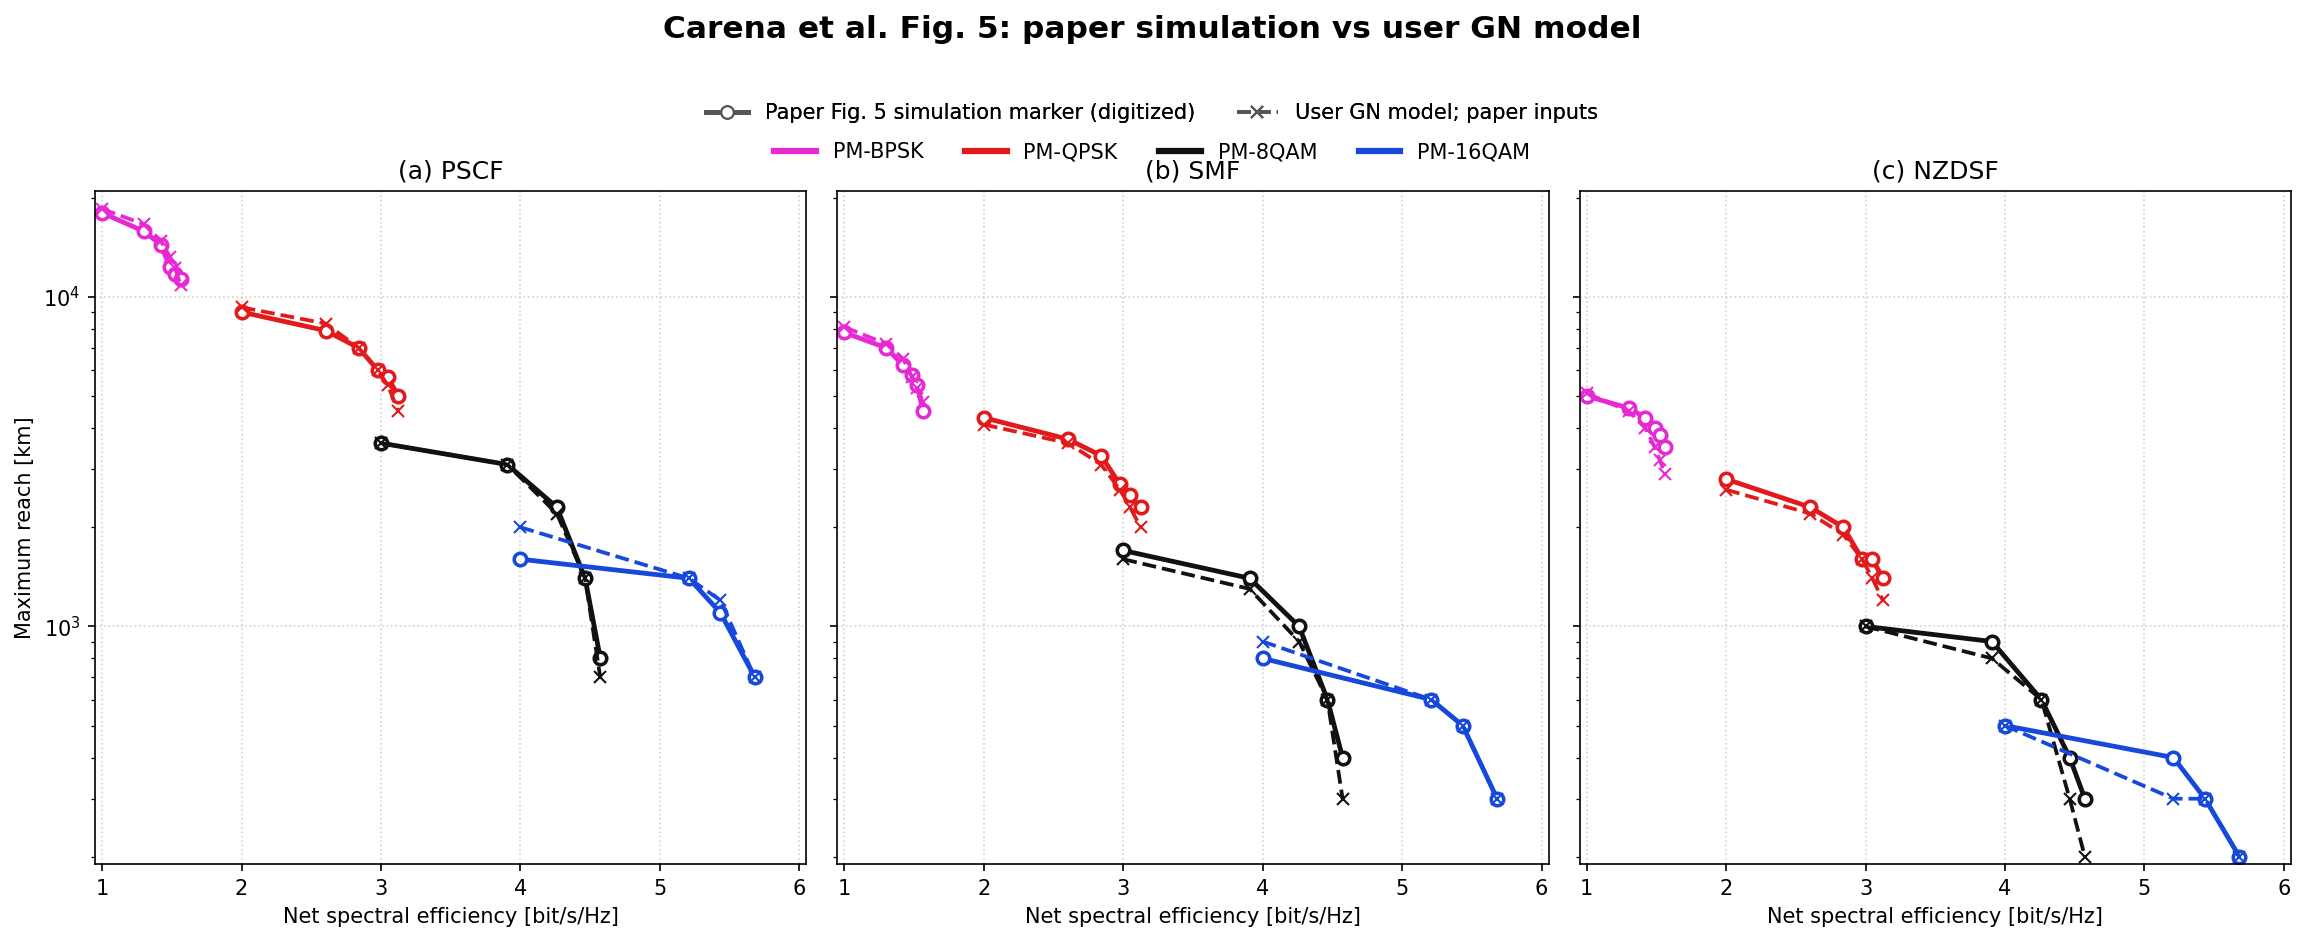

In [6]:
FORMAT_COLORS = {
    "PM-BPSK": "#e729d4",
    "PM-QPSK": "#e31a1c",
    "PM-8QAM": "#111111",
    "PM-16QAM": "#1648db",
}

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.8), sharey=True)

for panel, (ax, fiber_name) in enumerate(zip(axes, ["PSCF", "SMF", "NZDSF"])):
    for modulation in OSNR_REQUIRED_DB:
        subset = results[
            (results["Fiber"] == fiber_name)
            & (results["Modulation"] == modulation)
        ].sort_values("Net SE [bit/s/Hz]")
        color = FORMAT_COLORS[modulation]
        ax.plot(
            subset["Net SE [bit/s/Hz]"], subset["Paper [km]"],
            color=color, lw=2.3, marker="o", ms=6,
            markerfacecolor="white", markeredgewidth=1.7,
        )
        ax.plot(
            subset["Net SE [bit/s/Hz]"], subset["User GN [km]"],
            color=color, lw=1.8, ls="--", marker="x", ms=6,
        )
    ax.set_title(f"({chr(97 + panel)}) {fiber_name}")
    ax.set_xlim(0.95, 6.05)
    ax.set_ylim(190, 21000)
    ax.set_yscale("log")
    ax.set_xlabel("Net spectral efficiency [bit/s/Hz]")

axes[0].set_ylabel("Maximum reach [km]")

style_handles = [
    plt.Line2D([0], [0], color="#555", lw=2.3, marker="o", mfc="white",
               label="Paper Fig. 5 simulation marker (digitized)"),
    plt.Line2D([0], [0], color="#555", lw=1.8, ls="--", marker="x",
               label="User GN model; paper inputs"),
]
format_handles = [
    plt.Line2D([0], [0], color=color, lw=3, label=name)
    for name, color in FORMAT_COLORS.items()
]

legend1 = fig.legend(
    handles=style_handles, loc="upper center", ncol=2,
    frameon=False, bbox_to_anchor=(0.5, 1.00),
)
fig.add_artist(legend1)
fig.legend(
    handles=format_handles, loc="upper center", ncol=4,
    frameon=False, bbox_to_anchor=(0.5, 0.955),
)
fig.suptitle(
    "Carena et al. Fig. 5: paper simulation vs user GN model",
    y=1.08, fontsize=15, weight="bold",
)
fig.tight_layout()
plt.show()

In [7]:
representative_50ghz = results[results["Spacing [GHz]"] == 50][[
    "Fiber", "Modulation", "Paper [km]", "User GN [km]", "Error [%]", "Popt [dBm/ch]"
]].copy()

print("50-GHz REPRESENTATIVE COMPARISON")
print(representative_50ghz.round(3).to_string(index=False))

50-GHz REPRESENTATIVE COMPARISON
Fiber Modulation  Paper [km]  User GN [km]  Error [%]  Popt [dBm/ch]
 PSCF    PM-BPSK       18000       18500.0      2.778          0.350
 PSCF    PM-QPSK        9000        9300.0      3.333          0.425
 PSCF    PM-8QAM        3600        3600.0      0.000          0.450
 PSCF   PM-16QAM        1600        2000.0     25.000          0.500
  SMF    PM-BPSK        7800        8100.0      3.846          0.850
  SMF    PM-QPSK        4300        4100.0     -4.651          0.900
  SMF    PM-8QAM        1700        1600.0     -5.882          0.975
  SMF   PM-16QAM         800         900.0     12.500          1.000
NZDSF    PM-BPSK        5000        5100.0      2.000         -1.150
NZDSF    PM-QPSK        2800        2600.0     -7.143         -1.075
NZDSF    PM-8QAM        1000        1000.0      0.000         -1.000
NZDSF   PM-16QAM         500         500.0      0.000         -1.075


## 실행 결과 해석

실행 결과, 총 63개 지점의 전체 MAPE는 **6.589%**, 평균 signed bias는 **−3.497%**이다.

| Fiber | MAPE | 평균 편향 |
|---|---:|---:|
| PSCF | 4.78% | +1.38% |
| SMF | 5.74% | −2.81% |
| NZDSF | 9.25% | −9.06% |

PSCF와 SMF에서는 논문 Fig. 5의 최대 도달거리 경향을 비교적 정확하게 재현한다. 가장 큰 오차는 저분산 NZDSF와 32–33.6 GHz의 좁은 channel spacing에서 나타난다. 사용자 GN 모델의 평균 편향이 음수이므로 전체적으로 논문 simulation보다 도달거리를 약간 보수적으로 예측한다.

### 해석 시 주의사항

1. Fig. 3 required OSNR과 Fig. 5 marker는 논문 이미지 digitizing 값이므로 원시 데이터와 차이가 있을 수 있다.
2. 100 km span 단위 결과이므로 200–500 km 영역에서는 한 span 차이가 큰 상대오차가 된다.
3. 논문 Fig. 5는 incoherent NLI accumulation $N\eta P^3$을 사용하지만, 본 검증은 사용자 GN 모델을 그대로 유지하기 위해 $N^{1.05}\eta P^3$을 사용했다.
4. NZDSF처럼 분산이 낮은 조건에서는 Gaussianity 및 span accumulation 근사의 민감도가 커진다.
